In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# Dataset path
DATA_PATH = "/Users/riyarahimk/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1"

# See what's inside
print(os.listdir(DATA_PATH))

['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']


In [2]:
import tarfile, os

DATA_PATH = "/Users/riyarahimk/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1"
EXTRACT_PATH = "/Users/riyarahimk/mri-segmentation-pipeline/data/raw"

for f in os.listdir(DATA_PATH):
    if f.endswith('.tar'):
        print(f"Extracting {f}...")
        with tarfile.open(os.path.join(DATA_PATH, f)) as tar:
            tar.extractall(EXTRACT_PATH)
        print(f"Done: {f}")

print("\nExtracted:", os.listdir(EXTRACT_PATH))

Extracting BraTS2021_00495.tar...
Done: BraTS2021_00495.tar
Extracting BraTS2021_Training_Data.tar...


/var/folders/y3/vvq61cbs0s5dmvcz76fj7_d40000gn/T/ipykernel_72763/3320005908.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_PATH)


Done: BraTS2021_Training_Data.tar
Extracting BraTS2021_00621.tar...
Done: BraTS2021_00621.tar

Extracted: ['BraTS2021_00639', 'BraTS2021_01149', 'BraTS2021_00606', 'BraTS2021_01182', 'BraTS2021_00262', 'BraTS2021_01176', 'BraTS2021_01344', 'BraTS2021_00296', 'BraTS2021_01512', 'BraTS2021_00068', 'BraTS2021_01388', 'BraTS2021_01515', 'BraTS2021_01343', 'BraTS2021_00291', 'BraTS2021_01171', 'BraTS2021_01185', 'BraTS2021_00433', 'BraTS2021_00601', 'BraTS2021_01178', 'BraTS2021_00298', 'BraTS2021_00608', 'BraTS2021_01375', 'BraTS2021_00095', 'BraTS2021_01147', 'BraTS2021_01523', 'BraTS2021_00405', 'BraTS2021_00253', 'BraTS2021_01381', 'BraTS2021_00061', 'BraTS2021_00059', 'BraTS2021_00066', 'BraTS2021_00254', 'BraTS2021_01386', 'BraTS2021_00630', 'BraTS2021_00402', 'BraTS2021_01524', 'BraTS2021_01140', 'BraTS2021_01372', 'BraTS2021_00032', 'BraTS2021_01584', 'BraTS2021_00456', 'BraTS2021_00621_seg.nii.gz', 'BraTS2021_01570', 'BraTS2021_00690', 'BraTS2021_01326', 'BraTS2021_01114', 'BraTS20

In [3]:
import os

RAW = "/Users/riyarahimk/mri-segmentation-pipeline/data/raw"

# Check one sample
sample = os.path.join(RAW, "BraTS2021_00000")
print(os.listdir(sample))

['BraTS2021_00000_flair.nii.gz', 'BraTS2021_00000_t1ce.nii.gz', 'BraTS2021_00000_t1.nii.gz', 'BraTS2021_00000_seg.nii.gz', 'BraTS2021_00000_t2.nii.gz']


In [4]:

flair = nib.load(f"{sample}/BraTS2021_00000_flair.nii.gz").get_fdata()
t1    = nib.load(f"{sample}/BraTS2021_00000_t1.nii.gz").get_fdata()
t1ce  = nib.load(f"{sample}/BraTS2021_00000_t1ce.nii.gz").get_fdata()
t2    = nib.load(f"{sample}/BraTS2021_00000_t2.nii.gz").get_fdata()
seg   = nib.load(f"{sample}/BraTS2021_00000_seg.nii.gz").get_fdata()

print("Shape:", flair.shape)   # expect (240, 240, 155)
print("Seg labels:", np.unique(seg))  # expect [0, 1, 2, 4]

Shape: (240, 240, 155)
Seg labels: [0. 1. 2. 4.]


In [5]:
print(f"MRI is 3D: {flair.shape}")
print(f"= {flair.shape[0]}x{flair.shape[1]} pixels per slice")
print(f"= {flair.shape[2]} slices (top to bottom of brain)")
print(f"\nTumor classes in seg mask:")
print("0 = background (no tumor)")
print("1 = necrotic core (dead tumor cells)")
print("2 = edema (swelling around tumor)")
print("4 = enhancing tumor (active growing region)")

MRI is 3D: (240, 240, 155)
= 240x240 pixels per slice
= 155 slices (top to bottom of brain)

Tumor classes in seg mask:
0 = background (no tumor)
1 = necrotic core (dead tumor cells)
2 = edema (swelling around tumor)
4 = enhancing tumor (active growing region)


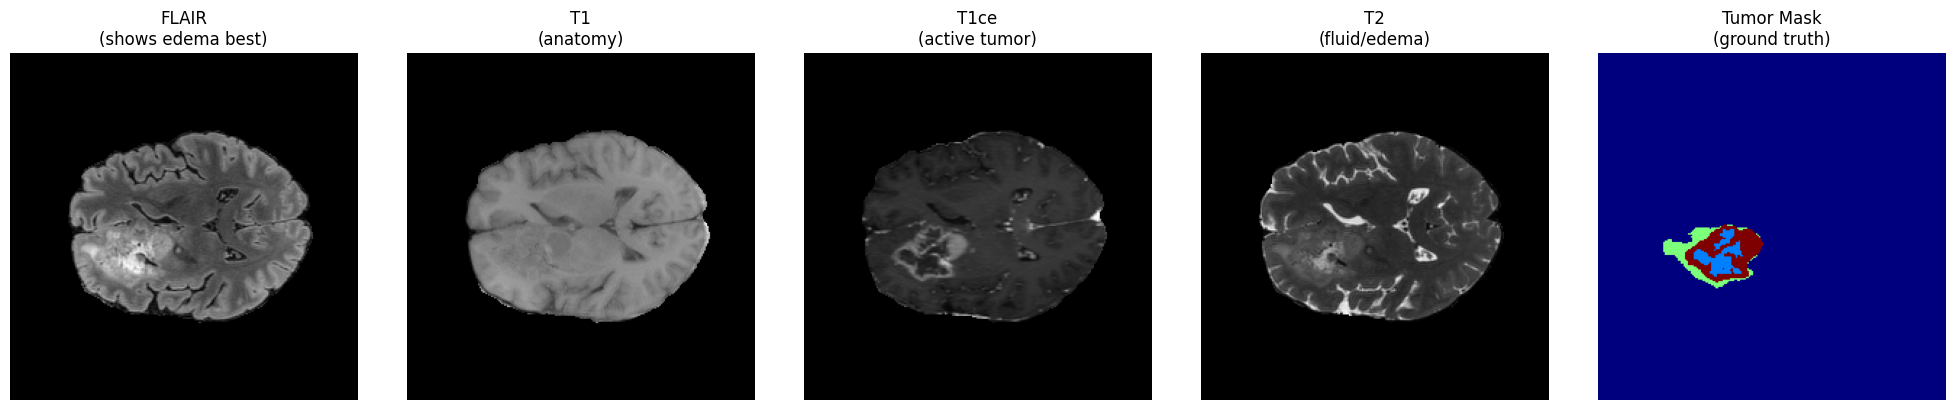

In [6]:
s = 77  # middle slice

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(flair[:,:,s], cmap='gray'); axes[0].set_title('FLAIR\n(shows edema best)')
axes[1].imshow(t1[:,:,s],    cmap='gray'); axes[1].set_title('T1\n(anatomy)')
axes[2].imshow(t1ce[:,:,s],  cmap='gray'); axes[2].set_title('T1ce\n(active tumor)')
axes[3].imshow(t2[:,:,s],    cmap='gray'); axes[3].set_title('T2\n(fluid/edema)')
axes[4].imshow(seg[:,:,s],   cmap='jet');  axes[4].set_title('Tumor Mask\n(ground truth)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig("sample_viz.png", dpi=150)
plt.show()

In [7]:
for name, vol in [('FLAIR',flair),('T1',t1),('T1ce',t1ce),('T2',t2)]:
    print(f"{name}: min={vol.min():.1f}, max={vol.max():.1f}, mean={vol.mean():.1f}")

FLAIR: min=0.0, max=2934.0, mean=163.7
T1: min=0.0, max=2023.0, mean=133.0
T1ce: min=0.0, max=12343.0, mean=345.5
T2: min=0.0, max=2421.0, mean=93.8


In [8]:
def normalize(volume):
    """Scale volume to 0-1, ignore background (0 values)"""
    min_val = volume.min()
    max_val = volume.max()
    if max_val == min_val:
        return volume
    return (volume - min_val) / (max_val - min_val)

flair_n = normalize(flair)
t1_n    = normalize(t1)
t1ce_n  = normalize(t1ce)
t2_n    = normalize(t2)

print("After normalization:")
for name, vol in [('FLAIR',flair_n),('T1',t1_n),('T1ce',t1ce_n),('T2',t2_n)]:
    print(f"{name}: min={vol.min():.3f}, max={vol.max():.3f}")

After normalization:
FLAIR: min=0.000, max=1.000
T1: min=0.000, max=1.000
T1ce: min=0.000, max=1.000
T2: min=0.000, max=1.000


In [9]:
# Stack: shape becomes (4, 240, 240, 155)
combined = np.stack([flair_n, t1_n, t1ce_n, t2_n], axis=0)
print("Combined input shape:", combined.shape)
print("= (4 modalities, 240, 240, 155 slices)")

Combined input shape: (4, 240, 240, 155)
= (4 modalities, 240, 240, 155 slices)


In [10]:
seg_fixed = seg.copy()
seg_fixed[seg_fixed == 4] = 3

print("Original labels:", np.unique(seg))
print("Fixed labels:   ", np.unique(seg_fixed))
print("\nLabel map:")
print("0 = background")
print("1 = necrotic core")
print("2 = edema")
print("3 = enhancing tumor (was 4)")

Original labels: [0. 1. 2. 4.]
Fixed labels:    [0. 1. 2. 3.]

Label map:
0 = background
1 = necrotic core
2 = edema
3 = enhancing tumor (was 4)


In [11]:
def crop_center(volume, crop_size=(128, 128, 128)):
    """Crop center of volume to crop_size"""
    x, y, z = volume.shape[-3], volume.shape[-2], volume.shape[-1]
    cx, cy, cz = crop_size
    sx = (x - cx) // 2
    sy = (y - cy) // 2
    sz = (z - cz) // 2
    if volume.ndim == 4:  # (4, 240, 240, 155)
        return volume[:, sx:sx+cx, sy:sy+cy, sz:sz+cz]
    else:  # (240, 240, 155)
        return volume[sx:sx+cx, sy:sy+cy, sz:sz+cz]

combined_crop = crop_center(combined)
seg_crop      = crop_center(seg_fixed)

print("Before crop:", combined.shape, seg_fixed.shape)
print("After crop: ", combined_crop.shape, seg_crop.shape)

Before crop: (4, 240, 240, 155) (240, 240, 155)
After crop:  (4, 128, 128, 128) (128, 128, 128)


In [13]:
import os
os.makedirs("data/processed", exist_ok=True)

np.save("data/processed/sample_input.npy", combined_crop.astype(np.float32))
np.save("data/processed/sample_mask.npy",  seg_crop.astype(np.uint8))

print("Saved!")
print("Input:", combined_crop.shape, combined_crop.dtype)
print("Mask: ", seg_crop.shape, seg_crop.dtype)

Fixed dtypes saved ✓


In [14]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm

RAW       = "/Users/riyarahimk/mri-segmentation-pipeline/data/raw"
PROCESSED = "/Users/riyarahimk/mri-segmentation-pipeline/data/processed"
os.makedirs(PROCESSED, exist_ok=True)

def normalize(vol):
    mi, ma = vol.min(), vol.max()
    return (vol - mi) / (ma - mi) if ma != mi else vol

def crop_center(vol, size=(128,128,128)):
    x,y,z = vol.shape[-3], vol.shape[-2], vol.shape[-1]
    sx,sy,sz = (x-size[0])//2, (y-size[1])//2, (z-size[2])//2
    if vol.ndim == 4:
        return vol[:, sx:sx+size[0], sy:sy+size[1], sz:sz+size[2]]
    return vol[sx:sx+size[0], sy:sy+size[1], sz:sz+size[2]]

# Get all patient folders
patients = sorted([
    p for p in os.listdir(RAW)
    if os.path.isdir(os.path.join(RAW, p)) and p.startswith("BraTS2021_")
])
print(f"Found {len(patients)} patients")

skipped = []
for pid in tqdm(patients):
    out_input = os.path.join(PROCESSED, f"{pid}_input.npy")
    out_mask  = os.path.join(PROCESSED, f"{pid}_mask.npy")
    
    # Skip if already processed
    if os.path.exists(out_input):
        continue
    
    try:
        base = os.path.join(RAW, pid, pid)
        flair = nib.load(f"{base}_flair.nii.gz").get_fdata()
        t1    = nib.load(f"{base}_t1.nii.gz").get_fdata()
        t1ce  = nib.load(f"{base}_t1ce.nii.gz").get_fdata()
        t2    = nib.load(f"{base}_t2.nii.gz").get_fdata()
        seg   = nib.load(f"{base}_seg.nii.gz").get_fdata()
        
        combined = np.stack([normalize(flair), normalize(t1),
                             normalize(t1ce),  normalize(t2)], axis=0)
        seg[seg == 4] = 3
        
        np.save(out_input, crop_center(combined).astype(np.float32))
        np.save(out_mask,  crop_center(seg).astype(np.uint8))
        
    except Exception as e:
        skipped.append((pid, str(e)))

print(f"\nDone! Skipped {len(skipped)} patients")
if skipped:
    for pid, err in skipped[:5]:
        print(f"  {pid}: {err}")

Found 1251 patients


100%|███████████████| 1251/1251 [09:25<00:00,  2.21it/s]


Done! Skipped 0 patients


In [15]:
import numpy as np
import os

PROCESSED = "/Users/riyarahimk/mri-segmentation-pipeline/data/processed"

files = os.listdir(PROCESSED)
inputs = [f for f in files if f.endswith("_input.npy")]
masks  = [f for f in files if f.endswith("_mask.npy")]

print(f"Input files: {len(inputs)}")
print(f"Mask files:  {len(masks)}")

# Load one and verify
sample_in = np.load(os.path.join(PROCESSED, inputs[0]))
sample_mk = np.load(os.path.join(PROCESSED, masks[0]))

print(f"\nSample input shape: {sample_in.shape}  dtype: {sample_in.dtype}")
print(f"Sample mask shape:  {sample_mk.shape}  dtype: {sample_mk.dtype}")
print(f"Input range: {sample_in.min():.3f} - {sample_in.max():.3f}")
print(f"Mask labels: {np.unique(sample_mk)}")

Input files: 1251
Mask files:  1251

Sample input shape: (4, 128, 128, 128)  dtype: float32
Sample mask shape:  (128, 128, 128)  dtype: uint8
Input range: 0.000 - 1.000
Mask labels: [0 1 2 3]


In [42]:
import torch
from torch.utils.data import Dataset, DataLoader

import random

class BraTSDatasetAug(Dataset):
    def __init__(self, processed_dir, patient_ids, augment=False):
        self.dir     = processed_dir
        self.ids     = patient_ids
        self.augment = augment
    
    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        pid = self.ids[idx]
        x = np.load(os.path.join(self.dir, f"{pid}_input.npy"))
        y = np.load(os.path.join(self.dir, f"{pid}_mask.npy"))
        
        if self.augment:
            # Random flip along each axis
            for axis in [1, 2, 3]:
                if random.random() > 0.5:
                    x = np.flip(x, axis=axis).copy()
                    y = np.flip(y, axis=axis-1).copy()
            
            # Random 90-degree rotation
            if random.random() > 0.5:
                k = random.randint(1, 3)
                x = np.rot90(x, k=k, axes=(2,3)).copy()
                y = np.rot90(y, k=k, axes=(1,2)).copy()
        
        return torch.tensor(x, dtype=torch.float32), \
               torch.tensor(y, dtype=torch.long)

# Train/val split — 80/20
all_ids = sorted([f.replace("_input.npy","") for f in inputs])
split   = int(0.8 * len(all_ids))
train_ids = all_ids[:split]
val_ids   = all_ids[split:]

train_ds = BraTSDataset(PROCESSED, train_ids)
val_ds   = BraTSDataset(PROCESSED, val_ids)

print(f"Train: {len(train_ds)} patients")
print(f"Val:   {len(val_ds)} patients")

# Test one batch loads correctly
x, y = train_ds[0]
print(f"\nInput tensor: {x.shape} {x.dtype}")
print(f"Mask tensor:  {y.shape} {y.dtype}")

print("Augmented dataset ready ✓")

Train: 1000 patients
Val:   251 patients

Input tensor: torch.Size([4, 128, 128, 128]) torch.float32
Mask tensor:  torch.Size([128, 128, 128]) torch.int64
Augmented dataset ready ✓


In [43]:
import torch
import torch.nn as nn

class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout3d(dropout),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class UNet3D(nn.Module):
    def __init__(self, in_channels=4, num_classes=4, features=[32,64,128,256]):
        super().__init__()
        
        # Encoder (downsampling path)
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv3D(ch, f))
            self.pools.append(nn.MaxPool3d(2))
            ch = f
        
        # Bottleneck (deepest layer)
        self.bottleneck = DoubleConv3D(features[-1], features[-1]*2)
        
        # Decoder (upsampling path)
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = features[-1]*2
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose3d(ch, f, kernel_size=2, stride=2))
            self.decoders.append(DoubleConv3D(f*2, f))
            ch = f
        
        # Final output layer
        self.final = nn.Conv3d(features[0], num_classes, kernel_size=1)
    
    def forward(self, x):
        # Encode
        skip_connections = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skip_connections.append(x)
            x = pool(x)
        
        x = self.bottleneck(x)
        
        # Decode
        skip_connections = skip_connections[::-1]  # reverse
        for upconv, dec, skip in zip(self.upconvs, self.decoders, skip_connections):
            x = upconv(x)
            x = torch.cat([x, skip], dim=1)  # skip connection
            x = dec(x)
        
        return self.final(x)

# Test model
model = UNet3D(in_channels=4, num_classes=4)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model created ✓")
print(f"Total parameters: {total_params:,}")

# Test forward pass with dummy data
dummy = torch.randn(1, 4, 128, 128, 128)
with torch.no_grad():
    out = model(dummy)
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}")  # expect (1, 4, 128, 128, 128)

Model created ✓
Total parameters: 22,583,908
Input:  torch.Size([1, 4, 128, 128, 128])
Output: torch.Size([1, 4, 128, 128, 128])


In [44]:
from torch.utils.data import DataLoader

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

## Fresh model with dropout
model = UNet3D(in_channels=4, num_classes=4, features=[16,32,64,128]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=7, factor=0.5
)

# 600 train, 100 val — with augmentation on train
train_loader = DataLoader(
    BraTSDatasetAug(PROCESSED, train_ids[:600], augment=True),
    batch_size=1, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    BraTSDatasetAug(PROCESSED, val_ids[:100], augment=False),
    batch_size=1, shuffle=False, num_workers=0
)

print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Train: {len(train_loader)} | Val: {len(val_loader)}")

Device: mps
Params: 5,649,204
Train: 600 | Val: 100


In [30]:
import time

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_dice   = {'necrotic':0, 'edema':0, 'enhancing':0, 'mean':0}
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item()
            scores = dice_score(pred, y)
            for k in all_dice:
                all_dice[k] += scores[k]
    n = len(loader)
    return total_loss/n, {k: v/n for k,v in all_dice.items()}

print("Training functions ready ✓")

Training functions ready ✓


In [ ]:
NUM_EPOCHS = 60
best_val_loss = float('inf')
history = {'train_loss':[], 'val_loss':[], 'dice_mean':[]}

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, dice = val_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['dice_mean'].append(dice['mean'])
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "models/best_model_v2.pth")
        flag = " ← best"
    else:
        flag = ""
    
    np.save("models/history_v2.npy", history)
    
    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train: {train_loss:.4f} | "
          f"Val: {val_loss:.4f} | "
          f"Dice: {dice['mean']:.4f} | "
          f"{elapsed:.0f}s{flag}", flush=True)

print(f"\nDone! Best val loss: {best_val_loss:.4f}")

In [46]:
import numpy as np

history = np.load("models/history_v2.npy", allow_pickle=True).item()
print(f"Epochs completed: {len(history['train_loss'])}")
print(f"Best dice: {max(history['dice_mean']):.4f}")
print(f"Last 3 epochs dice: {history['dice_mean'][-3:]}")

Epochs completed: 21
Best dice: 0.3822
Last 3 epochs dice: [0.33661691835453295, 0.3427845836724009, 0.1942236677096116]


In [47]:
# Load best v2 checkpoint
model.load_state_dict(torch.load("models/best_model_v2.pth", map_location=device))
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-5)  # lower LR
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
print("Resumed ✓")

Resumed ✓


In [49]:
NUM_EPOCHS = 60
best_val_loss = min(history['val_loss'])

for epoch in range(22, NUM_EPOCHS+1):
    t0 = time.time()
    
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, dice = val_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['dice_mean'].append(dice['mean'])
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "models/best_model_v2.pth")
        flag = " ← best"
    else:
        flag = ""
    
    np.save("models/history_v2.npy", history)
    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train: {train_loss:.4f} | "
          f"Val: {val_loss:.4f} | "
          f"Dice: {dice['mean']:.4f} | "
          f"{elapsed:.0f}s{flag}", flush=True)

Epoch 22/60 | Train: 0.2308 | Val: 1.5831 | Dice: 0.3293 | 2246s
Epoch 23/60 | Train: 0.2262 | Val: 1.2256 | Dice: 0.3498 | 2324s
Epoch 24/60 | Train: 0.2246 | Val: 1.0955 | Dice: 0.4008 | 2189s
Epoch 25/60 | Train: 0.2216 | Val: 2.1310 | Dice: 0.2891 | 2152s
Epoch 26/60 | Train: 0.2213 | Val: 1.7231 | Dice: 0.3281 | 2517s


KeyboardInterrupt: 

In [52]:
NUM_EPOCHS = 60
best_val_loss = min(history['val_loss'])

for epoch in range(28, NUM_EPOCHS+1):
    t0 = time.time()
    
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, dice = val_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['dice_mean'].append(dice['mean'])
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "models/best_model_v2.pth")
        flag = " ← best"
    else:
        flag = ""
    
    np.save("models/history_v2.npy", history)
    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train: {train_loss:.4f} | "
          f"Val: {val_loss:.4f} | "
          f"Dice: {dice['mean']:.4f} | "
          f"{elapsed:.0f}s{flag}", flush=True)

Epoch 28/60 | Train: 0.2247 | Val: 1.5121 | Dice: 0.3718 | 2425s
Epoch 29/60 | Train: 0.2216 | Val: 1.4058 | Dice: 0.3048 | 2020s
Epoch 30/60 | Train: 0.2180 | Val: 2.2111 | Dice: 0.3099 | 2018s
Epoch 31/60 | Train: 0.2170 | Val: 1.3084 | Dice: 0.3857 | 2181s
Epoch 32/60 | Train: 0.2082 | Val: 1.4914 | Dice: 0.3565 | 2311s
Epoch 33/60 | Train: 0.2084 | Val: 1.9357 | Dice: 0.3028 | 2195s
Epoch 34/60 | Train: 0.2102 | Val: 1.9583 | Dice: 0.2824 | 2008s
Epoch 35/60 | Train: 0.2080 | Val: 1.8275 | Dice: 0.3133 | 2006s
Epoch 36/60 | Train: 0.2063 | Val: 1.9071 | Dice: 0.3208 | 2014s
Epoch 37/60 | Train: 0.2060 | Val: 1.6340 | Dice: 0.3623 | 2010s
Epoch 38/60 | Train: 0.2034 | Val: 2.4218 | Dice: 0.2833 | 2017s
Epoch 39/60 | Train: 0.2047 | Val: 3.0929 | Dice: 0.2318 | 2012s
Epoch 40/60 | Train: 0.2030 | Val: 1.5364 | Dice: 0.3795 | 2041s
Epoch 41/60 | Train: 0.2028 | Val: 2.7597 | Dice: 0.2636 | 1918s
Epoch 42/60 | Train: 0.2025 | Val: 2.0886 | Dice: 0.3058 | 1860s
Epoch 43/60 | Train: 0.20

In [53]:
import numpy as np

history = np.load("models/history_v2.npy", allow_pickle=True).item()
print(f"Epochs completed: {len(history['train_loss'])}")
print(f"Best dice: {max(history['dice_mean']):.4f}")
print(f"Last 3 epochs dice: {history['dice_mean'][-3:]}")

Epochs completed: 60
Best dice: 0.4254
Last 3 epochs dice: [0.3461923650750759, 0.32806357036553296, 0.3811940886294057]
